## Analyze International E-Commerce Sales Performance

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [2]:
df = pd.read_csv('online_retail.csv')

In [3]:
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,01-12-2010 08:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,01-12-2010 08:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,01-12-2010 08:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,01-12-2010 08:28,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,01-12-2010 08:34,1.69,13047.0,United Kingdom


In [4]:
df.tail(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541899,581587,22726,ALARM CLOCK BAKELIKE GREEN,4,09-12-2011 12:50,3.75,12680.0,France
541900,581587,22730,ALARM CLOCK BAKELIKE IVORY,4,09-12-2011 12:50,3.75,12680.0,France
541901,581587,22367,CHILDRENS APRON SPACEBOY DESIGN,8,09-12-2011 12:50,1.95,12680.0,France
541902,581587,22629,SPACEBOY LUNCH BOX,12,09-12-2011 12:50,1.95,12680.0,France
541903,581587,23256,CHILDRENS CUTLERY SPACEBOY,4,09-12-2011 12:50,4.15,12680.0,France
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,09-12-2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,09-12-2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,09-12-2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,09-12-2011 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,09-12-2011 12:50,4.95,12680.0,France


## Explore Dataset

In [5]:
df.shape

(541909, 8)

In [6]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [8]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [9]:
df['InvoiceDate'] = pd.to_datetime(df.InvoiceDate, format = '%d-%m-%Y %H:%M')

In [10]:
df['CustomerID'] = df.CustomerID.astype('str')

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  str           
 1   StockCode    541909 non-null  str           
 2   Description  540455 non-null  str           
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  str           
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(1), str(5)
memory usage: 33.1 MB


In [12]:
df.describe()

,Quantity,InvoiceDate,UnitPrice
count,541909.000000,541909,541909.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114
min,-80995.000000,2010-12-01 08:26:00,-11062.060000
25%,1.000000,2011-03-28 11:34:00,1.250000
50%,3.000000,2011-07-19 17:17:00,2.080000
75%,10.000000,2011-10-19 11:27:00,4.130000
max,80995.000000,2011-12-09 12:50:00,38970.000000
std,218.081158,NaN,96.759853


In [13]:
df.memory_usage(index = True, deep = True) / 1024**2

Index           0.000126
InvoiceNo      28.433119
StockCode      27.952335
Description    39.033031
Quantity        4.134438
InvoiceDate     4.134438
UnitPrice       4.134438
CustomerID     25.849327
Country        32.236315
dtype: float64

In [14]:
df['Country'].value_counts()

Country
United Kingdom          495478
Germany                   9495
France                    8557
EIRE                      8196
Spain                     2533
Netherlands               2371
Belgium                   2069
Switzerland               2002
Portugal                  1519
Australia                 1259
Norway                    1086
Italy                      803
Channel Islands            758
Finland                    695
Cyprus                     622
Sweden                     462
Unspecified                446
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
Israel                     297
USA                        291
Hong Kong                  288
Singapore                  229
Iceland                    182
Canada                     151
Greece                     146
Malta                      127
United Arab Emirates        68
European Community          61
RSA                         58


In [15]:
df['Country'].unique()

<StringArray>
[      'United Kingdom',               'France',            'Australia',
          'Netherlands',              'Germany',               'Norway',
                 'EIRE',          'Switzerland',                'Spain',
               'Poland',             'Portugal',                'Italy',
              'Belgium',            'Lithuania',                'Japan',
              'Iceland',      'Channel Islands',              'Denmark',
               'Cyprus',               'Sweden',              'Austria',
               'Israel',              'Finland',              'Bahrain',
               'Greece',            'Hong Kong',            'Singapore',
              'Lebanon', 'United Arab Emirates',         'Saudi Arabia',
       'Czech Republic',               'Canada',          'Unspecified',
               'Brazil',                  'USA',   'European Community',
                'Malta',                  'RSA']
Length: 38, dtype: str

In [16]:
df['Country'].nunique()

38

In [17]:
df['CustomerID'].nunique()

4372

## Data Cleaning

In [18]:
df = df.dropna(subset = ['CustomerID'])

In [19]:
df.shape

(406829, 8)

In [20]:
df = df.drop_duplicates()

In [21]:
df.shape

(401604, 8)

In [22]:
df['TotalPrice'] = df.Quantity * df.UnitPrice

In [23]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


In [24]:
df_invalid = df[(df['Quantity'] <= 0) | (df['UnitPrice'] <= 0)]

In [25]:
df_invalid.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom,-27.50
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom,-4.65
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,-19.80
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,-6.96
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,-6.96


In [26]:
#### Removing cancelled invoices

In [27]:
df = df[~df['InvoiceNo'].str.startswith('C')]

## Important Note

Do not assume all negative quantities or zero prices are cancelled invoices.  
Investigate the data first before removing rows, as these values may represent returns, refunds, free items, or adjustments.

In [28]:
df[df['Quantity'] <= 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice


In [29]:
df[df['UnitPrice'] <= 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-05 14:02:00,0.0,12647.0,Germany,0.0
33576,539263,22580,ADVENT CALENDAR GINGHAM SACK,4,2010-12-16 14:36:00,0.0,16560.0,United Kingdom,0.0
40089,539722,22423,REGENCY CAKESTAND 3 TIER,10,2010-12-21 13:45:00,0.0,14911.0,EIRE,0.0
47068,540372,22090,PAPER BUNTING RETROSPOT,24,2011-01-06 16:41:00,0.0,13081.0,United Kingdom,0.0
47070,540372,22553,PLASTERS IN TIN SKULLS,24,2011-01-06 16:41:00,0.0,13081.0,United Kingdom,0.0
56674,541109,22168,ORGANISER WOOD ANTIQUE WHITE,1,2011-01-13 15:10:00,0.0,15107.0,United Kingdom,0.0
86789,543599,84535B,FAIRY CAKES NOTEBOOK A6 SIZE,16,2011-02-10 13:08:00,0.0,17560.0,United Kingdom,0.0
130188,547417,22062,CERAMIC BOWL WITH LOVE HEART DESIGN,36,2011-03-23 10:25:00,0.0,13239.0,United Kingdom,0.0
139453,548318,22055,MINI CAKE STAND HANGING STRAWBERY,5,2011-03-30 12:45:00,0.0,13113.0,United Kingdom,0.0
145208,548871,22162,HEART GARLAND RUSTIC PADDED,2,2011-04-04 14:42:00,0.0,14410.0,United Kingdom,0.0


Removing invalid Unit Price as `0`.

In [30]:
df = df[df['UnitPrice'] > 0]

In [31]:
df.sample(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
23554,538205,21500,PINK POLKADOT WRAP,25,2010-12-10 11:24:00,0.42,12748.0,United Kingdom,10.50
299971,563184,84522,PINK PARTY SUNGLASSES,1,2011-08-12 14:50:00,1.95,17516.0,United Kingdom,1.95
171367,551414,22678,FRENCH BLUE METAL DOOR SIGN 3,10,2011-04-28 13:35:00,1.25,15622.0,United Kingdom,12.50
107130,545411,22966,GINGERBREAD MAN COOKIE CUTTER,12,2011-03-02 12:21:00,1.25,16128.0,United Kingdom,15.00
530039,580774,22697,GREEN REGENCY TEACUP AND SAUCER,6,2011-12-06 11:05:00,2.95,13994.0,United Kingdom,17.70
132962,547712,22626,BLACK KITCHEN SCALES,1,2011-03-24 19:31:00,8.50,16905.0,United Kingdom,8.50
462145,575964,23332,IVORY WICKER HEART LARGE,1,2011-11-13 12:31:00,1.65,15021.0,United Kingdom,1.65
190232,553185,84971S,SMALL HEART FLOWERS HOOK,24,2011-05-15 12:35:00,0.85,17504.0,United Kingdom,20.40
315026,564715,21905,MORE BUTTER METAL SIGN,1,2011-08-28 11:01:00,0.79,14472.0,United Kingdom,0.79
180208,552309,21155,RED RETROSPOT PEG BAG,6,2011-05-08 15:22:00,2.55,13835.0,United Kingdom,15.30


## Filtering & Querying

**Q. Find all purchases from `Germany` and `France`**

In [32]:
df[(df['Country'] == 'Germany') | (df['Country'] == 'France')]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
26,536370,22728,ALARM CLOCK BAKELIKE PINK,24,2010-12-01 08:45:00,3.75,12583.0,France,90.00
27,536370,22727,ALARM CLOCK BAKELIKE RED,24,2010-12-01 08:45:00,3.75,12583.0,France,90.00
28,536370,22726,ALARM CLOCK BAKELIKE GREEN,12,2010-12-01 08:45:00,3.75,12583.0,France,45.00
29,536370,21724,PANDA AND BUNNIES STICKER SHEET,12,2010-12-01 08:45:00,0.85,12583.0,France,10.20
30,536370,21883,STARS GIFT TAPE,24,2010-12-01 08:45:00,0.65,12583.0,France,15.60
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


**Q. Find products with `UnitPrice > 100`**

In [33]:
df[df['UnitPrice'] >= 100]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
246,536392,22827,RUSTIC SEVENTEEN DRAWER SIDEBOARD,1,2010-12-01 10:29:00,165.00,13705.0,United Kingdom,165.00
4989,536835,22655,VINTAGE RED KITCHEN CABINET,1,2010-12-02 18:06:00,295.00,13145.0,United Kingdom,295.00
19428,537859,22828,REGENCY MIRROR WITH SHUTTERS,1,2010-12-08 16:11:00,165.00,14030.0,United Kingdom,165.00
19429,537859,22827,RUSTIC SEVENTEEN DRAWER SIDEBOARD,2,2010-12-08 16:11:00,145.00,14030.0,United Kingdom,290.00
25168,538354,22826,LOVE SEAT ANTIQUE WHITE METAL,2,2010-12-10 15:45:00,175.00,16873.0,United Kingdom,350.00
...,...,...,...,...,...,...,...,...,...
494728,578270,DOT,DOTCOM POSTAGE,1,2011-11-23 13:39:00,1270.06,14096.0,United Kingdom,1270.06
508459,579196,DOT,DOTCOM POSTAGE,1,2011-11-28 15:54:00,1526.76,14096.0,United Kingdom,1526.76
526015,580645,M,Manual,1,2011-12-05 13:11:00,219.50,17857.0,United Kingdom,219.50
528082,580727,DOT,DOTCOM POSTAGE,1,2011-12-05 17:17:00,1599.26,14096.0,United Kingdom,1599.26


**Q. Find transactions where `Quantity > 20` AND `Country == "United Kingdom"`**

In [34]:
df[(df['Quantity'] >= 20) & (df['Country'] == 'United Kingdom')]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom,54.08
46,536371,22086,PAPER CHAIN KIT 50'S CHRISTMAS,80,2010-12-01 09:00:00,2.55,13748.0,United Kingdom,204.00
65,536374,21258,VICTORIAN SEWING BOX LARGE,32,2010-12-01 09:09:00,10.95,15100.0,United Kingdom,350.40
82,536376,22114,HOT WATER BOTTLE TEA AND SYMPATHY,48,2010-12-01 09:32:00,3.45,15291.0,United Kingdom,165.60
83,536376,21733,RED HANGING HEART T-LIGHT HOLDER,64,2010-12-01 09:32:00,2.55,15291.0,United Kingdom,163.20
...,...,...,...,...,...,...,...,...,...
541876,581585,84945,MULTI COLOUR SILVER T-LIGHT HOLDER,24,2011-12-09 12:31:00,0.85,15804.0,United Kingdom,20.40
541882,581585,21916,SET 12 RETRO WHITE CHALK STICKS,24,2011-12-09 12:31:00,0.42,15804.0,United Kingdom,10.08
541883,581585,84692,BOX OF 24 COCKTAIL PARASOLS,25,2011-12-09 12:31:00,0.42,15804.0,United Kingdom,10.50
541891,581586,23275,SET OF 3 HANGING OWLS OLLIE BEAK,24,2011-12-09 12:49:00,1.25,13113.0,United Kingdom,30.00


**Q. Find top 10 most expensive products.**

In [35]:
# df['UnitPrice'].sort_values(ascending = False).head(10)

df.sort_values(by = 'UnitPrice', ascending = False).head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
173382,551697,POST,POSTAGE,1,2011-05-03 13:46:00,8142.75,16029.0,United Kingdom,8142.75
422351,573077,M,Manual,1,2011-10-27 14:13:00,4161.06,12536.0,France,4161.06
422376,573080,M,Manual,1,2011-10-27 14:20:00,4161.06,12536.0,France,4161.06
406406,571751,M,Manual,1,2011-10-19 11:18:00,3949.32,12744.0,Singapore,3949.32
374542,569382,M,Manual,1,2011-10-03 16:44:00,3155.95,15502.0,United Kingdom,3155.95
297438,562946,M,Manual,1,2011-08-11 09:38:00,2500.00,15581.0,United Kingdom,2500.00
144826,548813,M,Manual,1,2011-04-04 13:03:00,2382.92,12744.0,Singapore,2382.92
406407,571751,M,Manual,1,2011-10-19 11:18:00,2118.74,12744.0,Singapore,2118.74
144829,548820,M,Manual,1,2011-04-04 13:04:00,2053.07,12744.0,Singapore,2053.07
343000,566927,M,Manual,1,2011-09-15 15:20:00,2033.10,17846.0,United Kingdom,2033.10


**Q. Sort by largest `Quantity` sold.**

In [50]:
df.sort_values(by = 'Quantity', ascending = False).head(2)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom,168469.6
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,77183.6


**Q. Sort by highest `Revenue`.**

In [51]:
df.sort_values(by = 'TotalPrice', ascending = False)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.080,16446.0,United Kingdom,168469.600
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.040,12346.0,United Kingdom,77183.600
222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,2011-06-10 15:28:00,649.500,15098.0,United Kingdom,38970.000
173382,551697,POST,POSTAGE,1,2011-05-03 13:46:00,8142.750,16029.0,United Kingdom,8142.750
348325,567423,23243,SET OF TEA COFFEE SUGAR TINS PANTRY,1412,2011-09-20 11:05:00,5.060,17450.0,United Kingdom,7144.720
...,...,...,...,...,...,...,...,...,...
500313,578757,16216,LETTER SHAPE PENCIL SHARPENER,1,2011-11-25 11:41:00,0.060,12748.0,United Kingdom,0.060
359871,568200,PADS,PADS TO MATCH ALL CUSHIONS,1,2011-09-25 14:58:00,0.001,16198.0,United Kingdom,0.001
361741,568375,BANK CHARGES,Bank Charges,1,2011-09-26 17:01:00,0.001,13405.0,United Kingdom,0.001
279045,561226,PADS,PADS TO MATCH ALL CUSHIONS,1,2011-07-26 10:13:00,0.001,15618.0,United Kingdom,0.001


## GroupBy & Aggregation

**Q. Total revenue by country.**

In [37]:
df.groupby('Country')[['TotalPrice']].sum().sort_values(by = 'TotalPrice', ascending = False).head(10)

,TotalPrice
Country,
United Kingdom,7285024.644
Netherlands,285446.340
EIRE,265262.460
Germany,228678.400
France,208934.310
Australia,138453.810
Spain,61558.560
Switzerland,56443.950
Belgium,41196.340


**Q. `AOV` Average order value by country.**

In [38]:
order_value = df.groupby(['Country', 'InvoiceNo'])['TotalPrice'].sum()

In [39]:
aov_country = order_value.groupby('Country').mean().sort_values(ascending = False)

In [40]:
print(aov_country)

Country
Singapore               3039.898571
Netherlands             3036.663191
Australia               2429.014211
Japan                   1969.282632
Lebanon                 1693.880000
Israel                  1443.168000
Brazil                  1143.600000
Switzerland             1106.744118
Sweden                  1065.773056
Denmark                 1053.074444
EIRE                    1020.240231
Norway                  1004.595556
RSA                     1002.310000
Greece                   952.104000
Cyprus                   843.928125
Channel Islands          786.174615
USA                      716.078000
Spain                    683.984000
United Arab Emirates     634.093333
Iceland                  615.714286
Canada                   611.063333
Austria                  599.922353
Portugal                 585.541053
Finland                  549.904390
Malta                    545.118000
France                   537.106195
Germany                  500.390372
Italy               

**Q. Top 10 customers by spending.**

In [41]:
df.groupby('CustomerID')[['TotalPrice']].sum().sort_values(by = 'TotalPrice', ascending = False).head(10)

,TotalPrice
CustomerID,
14646.0,280206.02
18102.0,259657.30
17450.0,194390.79
16446.0,168472.50
14911.0,143711.17
12415.0,124914.53
14156.0,117210.08
17511.0,91062.38
16029.0,80850.84


**Q. Most sold products.**

In [42]:
df.groupby('Description')['Quantity'].sum().sort_values(ascending = False).head(10)

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

**Q. Average quantity purchased per customer.**

In [43]:
df.groupby('CustomerID')['Quantity'].mean().sort_values(ascending = False).head(10)

CustomerID
12346.0    74215.0
16446.0    26999.0
13135.0     4300.0
16754.0     2140.0
16308.0     2000.0
18087.0     1953.5
15749.0     1802.8
14609.0     1756.5
15118.0     1440.0
15195.0     1404.0
Name: Quantity, dtype: float64

**Q. Count transactions per country.**

In [44]:
df.groupby('Country')['InvoiceNo'].nunique().sort_values(ascending = False).head(10)

Country
United Kingdom    16646
Germany             457
France              389
EIRE                260
Belgium              98
Netherlands          94
Spain                90
Portugal             57
Australia            57
Switzerland          51
Name: InvoiceNo, dtype: int64

## Merging

In [45]:
data = {
    'CustomerID': [17850.0, 13047.0, 12583.0, 13748.0, 15100.0, 14688.0, 17511.0, 16029.0, 14156.0, 14911.0,
                   13694.0, 15311.0, 14527.0, 12748.0, 15061, 12415.0, 18118.0, 17450.0, 13263.0, 14096.0],
    'Segment': ['Premium', 'Gold', 'Silver', 'Gold', 'Premium', 'Silver', 'Gold', 'Premium', 'Silver', 'Gold',
                'Premium', 'Gold', 'Silver', 'Premium', 'Gold', 'Silver', 'Premium', 'Gold', 'Silver', 'Premium']
}

# Create DataFrame and save to CSV
customers = pd.DataFrame(data)
customers.to_csv('customers.csv', index=False)

In [46]:
print(df['CustomerID'].dtype)
print(customers['CustomerID'].dtype)

str
float64


In [47]:
customers['CustomerID'] = customers['CustomerID'].astype(str)

In [48]:
merged_df = pd.merge(df, customers, on='CustomerID', how='inner')

In [49]:
segment_revenue = (
    merged_df.groupby('Segment')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
)

print(segment_revenue)

Segment
Gold       548517.02
Silver     270929.15
Premium    256000.73
Name: TotalPrice, dtype: float64


## Plotting

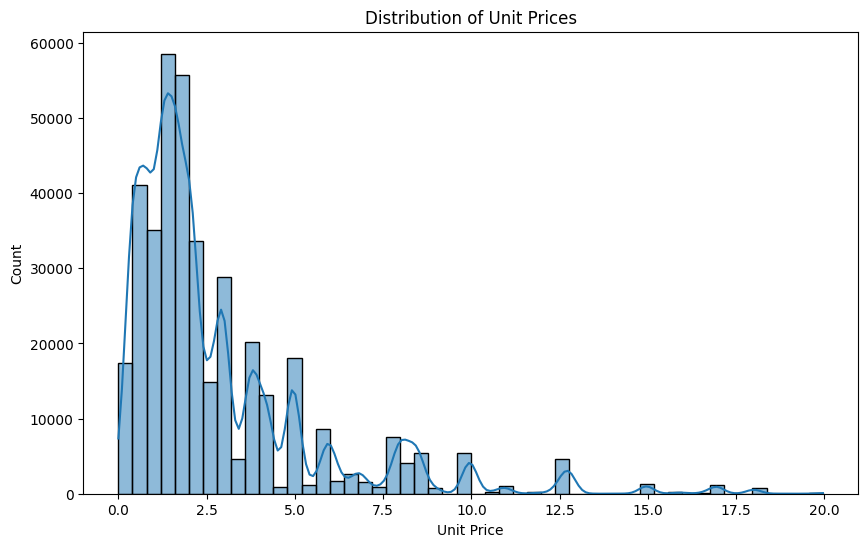

count    391569.000000
mean          2.812852
std           2.789178
min           0.001000
25%           1.250000
50%           1.950000
75%           3.750000
max          19.960000
Name: UnitPrice, dtype: float64


In [62]:
df_filtered = df[df['UnitPrice'] < 20]

plt.figure(figsize=(10, 6))
sns.histplot(df_filtered["UnitPrice"], bins=50, kde=True)
plt.title("Distribution of Unit Prices")
plt.xlabel("Unit Price")
plt.ylabel("Count")
plt.show()

print(df_filtered["UnitPrice"].describe())

<Axes: xlabel='UnitPrice', ylabel='Quantity'>

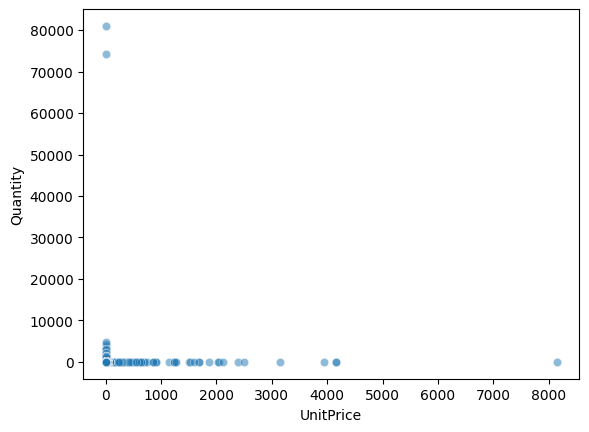

In [64]:
sns.scatterplot(x = df.UnitPrice, y = df.Quantity, alpha = 0.5)